# Cheaper fares, cleaner air? Exploratory visualisations

**Project:** Measuring the environmental ripple effects of Queensland's 50-cent public transport fare.

This notebook is the *look-before-you-model* stage. Every chart answers one question tied to a research
question (RQ1 to RQ5). Each chart has a short note above it on **what it shows** and **what to look for**, and a
**What we learn** box below it with the conclusion in plain words. Nothing here is a final result. The point is to see
the shape of the data, spot the signals worth modelling, and spot the traps (seasonality, weather, COVID) that a model must handle.

| Research question | Charts |
|---|---|
| RQ1 Did the fare cut genuinely increase public transport use? | 1.1 to 1.5 |
| RQ2 Did driving fall? | 2.1 to 2.3 |
| RQ3 Did carbon emissions fall? | 3.1 |
| RQ4 Did roadside air quality improve? | 4.1 to 4.5 |
| RQ5 Were drivers ever on the margin (fuel-price sensitivity)? | 5.1 to 5.3 |
| Side effects worth knowing about | 6.1 to 6.3 |


Key dates used throughout: **5 Aug 2024** fares drop to 50 cents (red line). **Feb 2025** made permanent (dotted red line).
**23 Mar to 31 May 2020** COVID lockdown (grey band).

In [1]:
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
RAW, CLEAN = ROOT / "data" / "raw", ROOT / "data" / "clean"
FIG = ROOT / "docs" / "figures" / "eda"; FIG.mkdir(parents=True, exist_ok=True)

POLICY    = pd.Timestamp("2024-08-05")
PERMANENT = pd.Timestamp("2025-02-03")
LOCKDOWN  = (pd.Timestamp("2020-03-23"), pd.Timestamp("2020-05-31"))
PRE  = ("2023-08-01", "2024-07-31")   # 12 months before the policy
POST = ("2024-08-01", "2025-07-31")   # 12 months after

# ---- palette: validated categorical slots + chart chrome (see docs on the dataviz method) ----
BLUE, ORANGE, AQUA, YELLOW, RED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948"
BLUE_DARK, BLUE_LIGHT = "#1c5cab", "#86b6ef"
GRAY_L, GRAY_M, GRAY_D = "#c3c2b7", "#a3a29a", "#898781"      # de-emphasis greys, light -> dark
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-", "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titleweight": "semibold", "axes.titlesize": 11,
    "font.size": 9, "font.family": "sans-serif", "lines.linewidth": 1.8,
    "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "legend.fontsize": 8.5, "figure.dpi": 110,
})

def new_fig(w=11, h=4):
    return plt.subplots(figsize=(w, h))

def policy_line(ax, label="50c fares start"):
    ax.axvline(POLICY, color=RED, lw=1.1)
    ax.axvline(PERMANENT, color=RED, lw=0.8, ls=(0, (2, 3)))
    if label:
        ax.annotate(label, xy=(POLICY, 1), xycoords=("data", "axes fraction"),
                    xytext=(4, -3), textcoords="offset points", color=RED, va="top", fontsize=8)

def lockdown_band(ax):
    ax.axvspan(*LOCKDOWN, color=GRID, alpha=0.7, lw=0)

def end_label(ax, x, y, text, color=INK2, dx=5):
    ax.annotate(text, (x, y), xytext=(dx, 0), textcoords="offset points", va="center", fontsize=8.5, color=color)

def index_to(s, start, end):
    # rebase a series so its mean over [start, end] equals 100
    return 100 * s / s[start:end].mean()

def spread(ys, min_gap):
    # nudge label positions apart so none sit closer than min_gap (keeps their order)
    ys = np.array(ys, dtype=float); order = np.argsort(ys)
    for a, b in zip(order[:-1], order[1:]):
        if ys[b] - ys[a] < min_gap:
            ys[b] = ys[a] + min_gap
    return ys

def week_of_year(idx):
    # 1..53 by day-of-year, so the first days of January never fall into "week 52" of the prior year
    return (idx.dayofyear - 1) // 7 + 1

def show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")
    plt.show()

print("project root:", ROOT)

project root: C:\Users\Sai Veshwa\Documents\DS-PROJECT


## Load the tidy series

Everything below comes from `data/clean/` (built by `scripts/check_plots.py`) plus a few small raw Translink files.
The weekly trips series is re-indexed to a complete weekly calendar so the missing weeks in early 2026 show as gaps, not as zeros.

In [2]:
# Weekly SEQ public transport trips, all modes, 2012 -> 2026 (9 weeks missing Feb-Mar 2026)
trips = pd.read_csv(CLEAN / "seq_weekly_trips.csv", parse_dates=["week_ending"]).set_index("week_ending")["trips"]
trips = trips.reindex(pd.date_range(trips.index.min(), trips.index.max(), freq="W-SUN"))

# Weekly SEQ unleaded price (cents per litre)
fuel = pd.read_csv(CLEAN / "seq_weekly_unleaded_price.csv", parse_dates=["week_ending"]).set_index("week_ending")["ulp_cpl"]

# Monthly petrol sales by state (megalitres)
petrol = (pd.read_csv(CLEAN / "petrol_sales_by_state_monthly.csv", parse_dates=["Month"])
            .pivot(index="Month", columns="State", values="petrol_ML"))

# Hourly NO2 at two roadside and two background monitors (ppb)
no2 = pd.read_csv(CLEAN / "no2_hourly_selected_sites.csv", parse_dates=["ts"])
no2["hour"], no2["weekday"] = no2.ts.dt.hour, no2.ts.dt.dayofweek < 5

# Trips per day, QLD SEQ vs NSW bus (control)
compare = (pd.read_csv(CLEAN / "qld_vs_nsw_monthly_trips.csv", parse_dates=["month"])
             .pivot(index="month", columns="region", values="trips"))

# Monthly trips by mode (SEQ), only published from Dec 2023. Modes: Bus, Citytrain, Ferry, "Tram".
# "Tram" is Translink's label for the Gold Coast light rail (G:link). Brisbane has no trams.
modes = pd.read_csv(RAW / "translink_monthly" / "patronage_seq.csv")
modes["month"] = pd.to_datetime(modes["Month-Year"], format="%b-%Y")
modes = modes.pivot(index="month", columns="Mode", values="Passenger trips").sort_index()

# Monthly fines and warnings
fines = pd.read_csv(RAW / "translink_monthly" / "passenger_fines_and_warnings.csv")
fines["month"] = pd.to_datetime(fines["Month-Year"], format="%b-%Y")
fines = fines.set_index("month")[["Passenger fines", "Passenger warnings"]].sort_index()

# Weekly complaints per 10,000 trips (non go card) and weekly go card trips
comp = pd.read_csv(RAW / "translink_monthly" / "patronage_and_complaints.csv")
comp["week_ending"] = pd.to_datetime(comp["Week ending"].str.replace(" 12:00 AM", "", regex=False), format="%a, %d %b %Y")
complaints = comp.set_index("week_ending").iloc[:, 5].rename("complaints_per_10k").sort_index()   # 6th column: other-than-go-card complaints per 10k trips
gc = pd.read_csv(RAW / "translink_monthly" / "go_card_fixed_fare_adjustments.csv")
gc["week_ending"] = pd.to_datetime(gc["Week ending"].str.replace(" 12:00 AM", "", regex=False), format="%a, %d %b %Y")
gocard = pd.to_numeric(gc.set_index("week_ending")["Go Card Trips"], errors="coerce").sort_index()

print(f"trips {trips.index.min().date()} -> {trips.index.max().date()} | fuel {fuel.index.min().date()} -> {fuel.index.max().date()} | "
      f"petrol -> {petrol.index.max().date()} | NO2 -> {no2.ts.max().date()} | modes {modes.index.min().date()} -> {modes.index.max().date()}")

trips 2012-07-08 -> 2026-05-31 | fuel 2019-01-06 -> 2026-09-06 | petrol -> 2026-06-01 | NO2 -> 2025-12-31 | modes 2023-12-01 -> 2026-05-01


## RQ1. Did the fare cut genuinely increase public transport use?

### 1.1 The whole history in one line
**What it shows:** weekly trips across all SEQ modes since 2018.
**Look for:** the COVID crater in 2020, the slow climb back, and whether the level after August 2024 is a visible step up rather than just a continuation of the recovery trend.

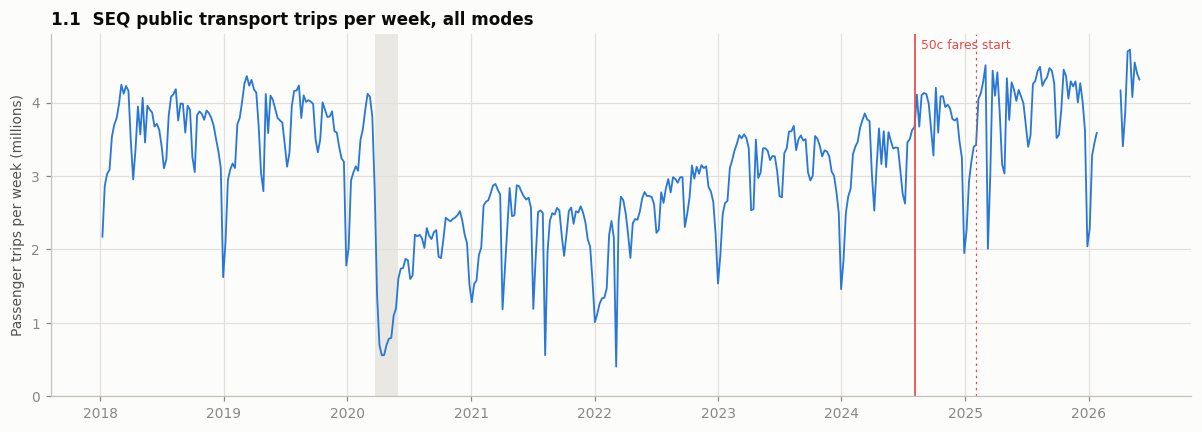

In [3]:
fig, ax = new_fig()
s = trips["2018":]
ax.plot(s.index, s / 1e6, color=BLUE, lw=1.2)
lockdown_band(ax); policy_line(ax)
ax.set_ylabel("Passenger trips per week (millions)")
ax.set_title("1.1  SEQ public transport trips per week, all modes")
ax.set_ylim(0, None)
show(fig, "1_1_weekly_trips_history")

> **What we learn:** Ridership was still climbing back from COVID when the fare cut arrived. After August 2024 it stepped up again and kept rising: the busiest week on record is May 2026 at 4.7 million trips, above anything seen before COVID. The step at the red line is visible without any statistics.

### 1.2 Seasonal overlay: the policy year against earlier years
**What it shows:** each year drawn on the same January-to-December axis. Earlier years are grey, the policy period is blue.
**Look for:** the 2024 line turning blue in August and jumping above 2023. If 2025 sits above *every* grey line in *every* season, including above pre-COVID 2019, the increase is not a seasonal artefact.

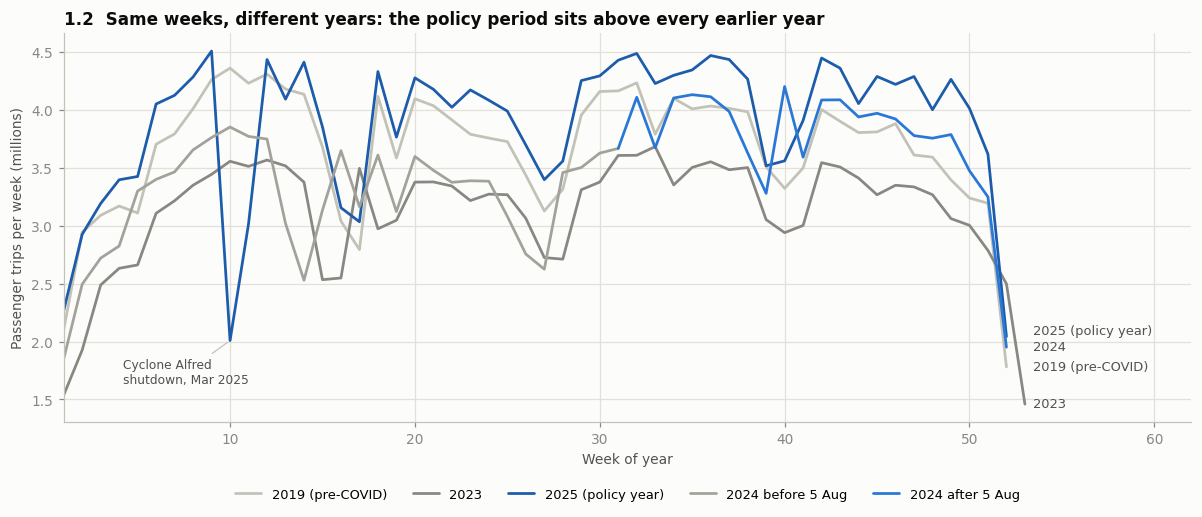

In [4]:
fig, ax = new_fig(11, 4.8)
years = {2019: (GRAY_L, "2019 (pre-COVID)"), 2023: (GRAY_D, "2023"), 2025: (BLUE_DARK, "2025 (policy year)")}
ends = {}
for yr, (col, lab) in years.items():
    s = trips[str(yr)]
    ax.plot(week_of_year(s.index), s / 1e6, color=col, label=lab)
    ends[lab] = s.iloc[-1] / 1e6
s24 = trips["2024"]; wk = week_of_year(s24.index)
pre, post = s24.index < POLICY, s24.index >= POLICY - pd.Timedelta(days=7)
ax.plot(wk[pre], s24[pre] / 1e6, color=GRAY_M, label="2024 before 5 Aug")
ax.plot(wk[post], s24[post] / 1e6, color=BLUE, label="2024 after 5 Aug")
ends["2024"] = s24.iloc[-1] / 1e6
for lab, y in zip(ends, spread(list(ends.values()), 0.14)):
    end_label(ax, 53, y, lab)
alfred = trips["2025-03-09"] / 1e6
ax.annotate("Cyclone Alfred\nshutdown, Mar 2025", xy=(week_of_year(pd.DatetimeIndex(["2025-03-09"]))[0], alfred),
            xytext=(-70, -28), textcoords="offset points", fontsize=8, color=INK2,
            arrowprops=dict(arrowstyle="-", color=AXIS, lw=0.8))
ax.set_xlabel("Week of year"); ax.set_ylabel("Passenger trips per week (millions)")
ax.set_title("1.2  Same weeks, different years: the policy period sits above every earlier year")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=5); ax.set_xlim(1, 62)
show(fig, "1_2_seasonal_overlay")

> **What we learn:** In 48 of the 52 weeks of 2025, trips were higher than the same week in 2019, the best pre-COVID year. The 2024 line turns blue in August and jumps above 2023 straight away. The increase is not a seasonal quirk or a slow recovery: it is a level shift that shows up in every part of the year. The one deep dip is the Cyclone Alfred shutdown in March 2025.

### 1.3 Year-on-year change, week by week
**What it shows:** each week's trips compared with the same week a year earlier. Blue bars are above last year, red below.
**Look for:** a sudden jump to roughly +15 to +20 per cent at the red line, and whether it *stays* there for the following year (a lasting habit) or fades (novelty). From August 2025 the comparison is policy-year against policy-year, so the bars should fall back toward zero, and any remaining growth is organic.

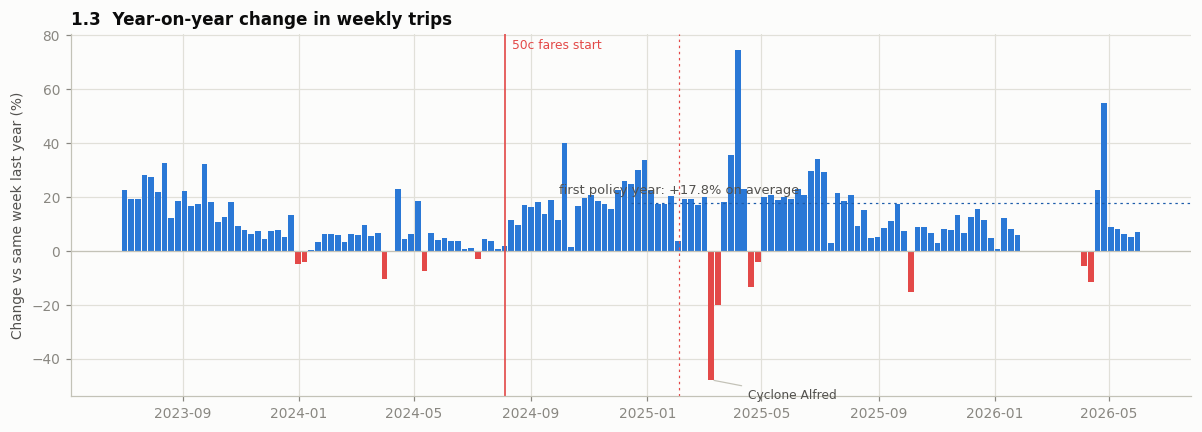

In [5]:
yoy = 100 * (trips / trips.shift(52) - 1)
s = yoy["2023-07":]          # earlier weeks compare against 2022 flood and COVID weeks and swing by hundreds of per cent
fig, ax = new_fig()
ax.bar(s.index, s.clip(lower=0), width=6, color=BLUE, lw=0)
ax.bar(s.index, s.clip(upper=0), width=6, color=RED, lw=0)
ax.axhline(0, color=AXIS, lw=0.8)
policy_line(ax)
m = yoy[POLICY:POLICY + pd.Timedelta(weeks=52)].mean()
ax.axhline(m, color=BLUE_DARK, lw=0.8, ls=(0, (2, 3)), xmin=0.5)
ax.annotate(f"first policy year: {m:+.1f}% on average", xy=(POLICY + pd.Timedelta(weeks=26), m),
            xytext=(0, 6), textcoords="offset points", ha="center", color=INK2, fontsize=8.5)
alfred = s["2025-03-09"]
ax.annotate("Cyclone Alfred", xy=(pd.Timestamp("2025-03-09"), alfred), xytext=(24, -6), textcoords="offset points",
            fontsize=8, color=INK2, va="top", arrowprops=dict(arrowstyle="-", color=AXIS, lw=0.8))
ax.set_ylabel("Change vs same week last year (%)")
ax.set_title("1.3  Year-on-year change in weekly trips")
show(fig, "1_3_yoy_change")

> **What we learn:** Trips were on average 17.8 per cent higher than a year earlier during the first policy year, and the jump started the week fares changed. From August 2025 the comparison is policy year against policy year, and growth settles back to about 9 per cent. That is the important part: the new riders did not drift away. If they had, these later bars would be negative.

### 1.4 Which modes grew most?
**What it shows:** monthly trips per mode, rebased so the eight pre-policy months (Dec 2023 to Jul 2024) average 100.
**Look for:** ferry and the Gold Coast light rail, the leisure-heavy modes, pulling away from bus and train. Translink's data calls the light rail "Tram"; Brisbane has no trams, so the label is renamed here. That pattern points to *new* trips (a Sunday ferry to the city) rather than car commutes being replaced, which matters for every environmental question that follows.

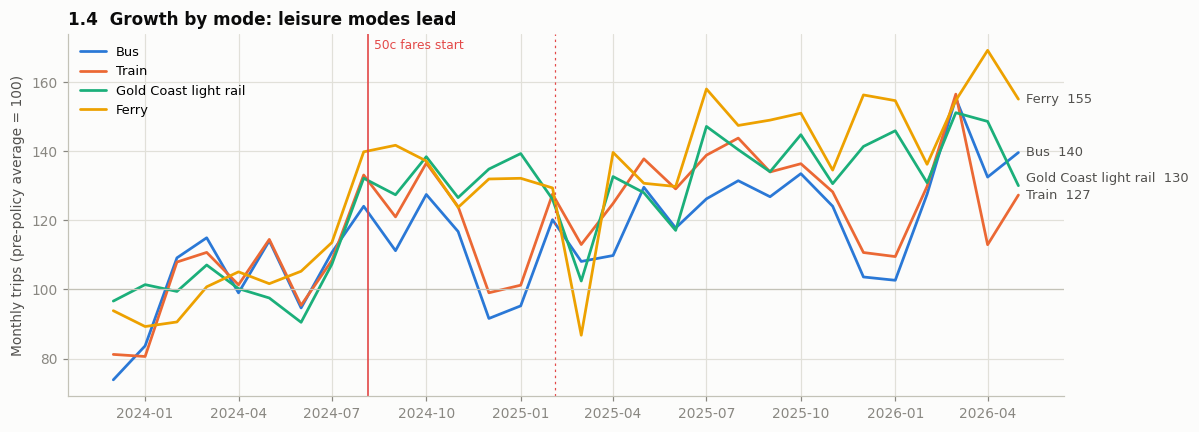

In [6]:
idx = modes.apply(lambda c: index_to(c, "2023-12-01", "2024-07-01"))
idx = idx.rename(columns={"Citytrain": "Train", "Tram": "Gold Coast light rail"})   # Translink's "Tram" is the G:link; Brisbane has no trams
colors = {"Bus": BLUE, "Train": ORANGE, "Gold Coast light rail": AQUA, "Ferry": YELLOW}
fig, ax = new_fig()
last = idx.iloc[-1]
for (mode, col), y in zip(colors.items(), spread([last[m] for m in colors], 5)):
    ax.plot(idx.index, idx[mode], color=col, label=mode)
    end_label(ax, idx.index[-1], y, f"{mode}  {last[mode]:.0f}")
ax.axhline(100, color=AXIS, lw=0.8)
policy_line(ax)
ax.set_ylabel("Monthly trips (pre-policy average = 100)")
ax.set_title("1.4  Growth by mode: leisure modes lead")
ax.legend(loc="upper left")
show(fig, "1_4_growth_by_mode")

> **What we learn:** Every mode grew, but not equally. Over the first policy year ferry trips were up about 32 per cent and Gold Coast light rail trips 29 per cent, against 24 per cent for trains and only 15 per cent for buses. The ferries are Brisbane's CityCats and cross-river ferries, and the light rail runs along the Gold Coast beach strip. Both are used far more for outings than for commuting, so a large share of the new trips look like extra outings, not car commutes replaced. Buses, the biggest mode, grew least. The ferry dip in March 2025 is Cyclone Alfred, when ferries were suspended. (Translink labels the light rail "Tram" in its data. Brisbane itself has no trams.)

### 1.5 Queensland against a state that did not cut fares
**What it shows:** trips per day in SEQ (all modes) and on Sydney buses, both rebased to 2023 = 100. The lower panel is simply the gap between them, which is the raw material of a difference-in-differences estimate.
**Look for:** the two lines tracking each other closely before August 2024 (that is what makes NSW a credible control), then the gap opening at the red line and staying open.

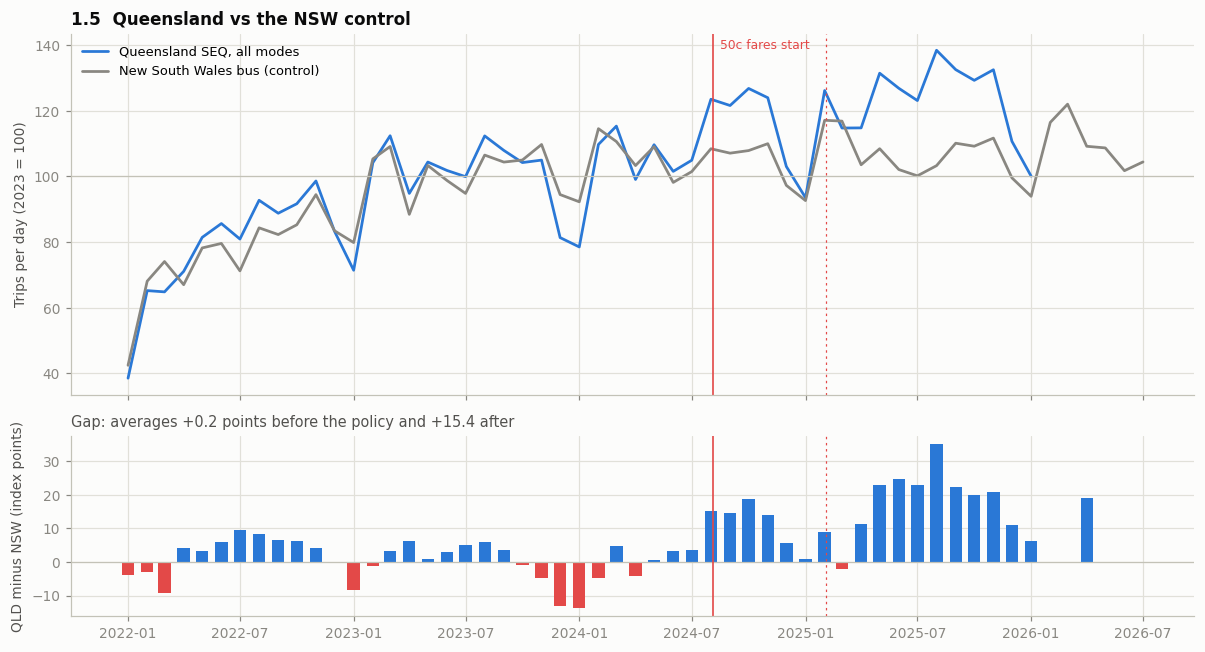

In [7]:
q = index_to(compare["QLD SEQ all modes"], "2023-01-01", "2023-12-01")
n = index_to(compare["NSW bus"], "2023-01-01", "2023-12-01")
gap = (q - n)["2022":]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(q["2022":].index, q["2022":], color=BLUE, label="Queensland SEQ, all modes")
ax1.plot(n["2022":].index, n["2022":], color=GRAY_D, label="New South Wales bus (control)")
ax1.axhline(100, color=AXIS, lw=0.8); policy_line(ax1); ax1.legend(loc="upper left")
ax1.set_ylabel("Trips per day (2023 = 100)"); ax1.set_title("1.5  Queensland vs the NSW control")
ax2.bar(gap.index, gap.clip(lower=0), width=20, color=BLUE, lw=0)
ax2.bar(gap.index, gap.clip(upper=0), width=20, color=RED, lw=0)
ax2.axhline(0, color=AXIS, lw=0.8); policy_line(ax2, label=None)
ax2.set_ylabel("QLD minus NSW (index points)")
post_gap = gap[POLICY:].mean(); pre_gap = gap["2023":POLICY].mean()
ax2.set_title(f"Gap: averages {pre_gap:+.1f} points before the policy and {post_gap:+.1f} after", fontsize=9.5, color=INK2, weight="normal")
show(fig, "1_5_qld_vs_nsw_gap")

> **What we learn:** Before the policy, Brisbane and Sydney moved together: the gap between them averaged almost exactly zero. After August 2024 Brisbane pulled ahead by about 15 index points and stayed there. Sydney felt the same national forces (population growth, return to the office, cost of living) but did not cut fares, so that 15-point gap is our first estimate of the fare cut's own effect.

## RQ2. Did driving fall?

### 2.1 Petrol sales, Queensland against two control states
**What it shows:** monthly automotive petrol sold in each state, rebased to 2023 = 100.
**Look for:** whether Queensland drifts below NSW and Victoria after August 2024. All three share national forces (prices, electric-vehicle uptake, fuel efficiency), so only a *relative* dip counts as evidence.

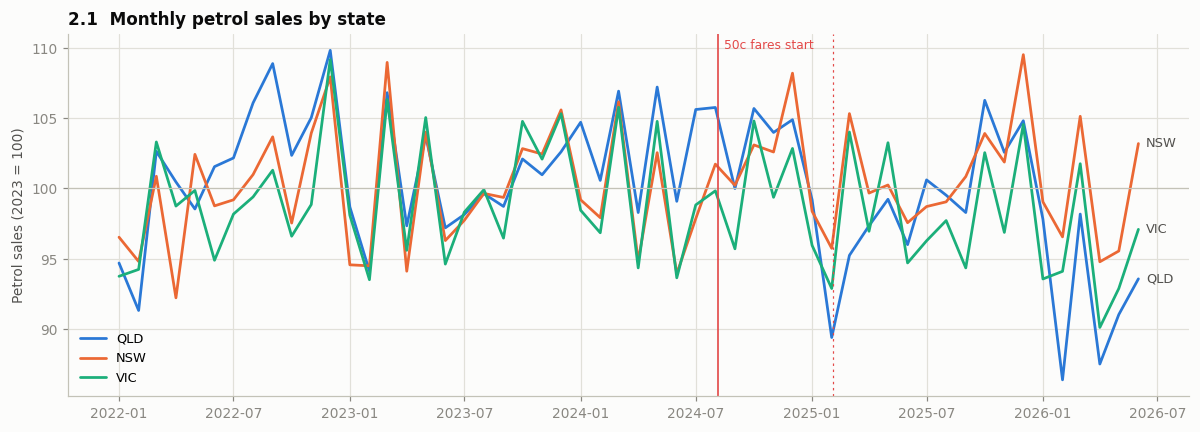

In [8]:
fig, ax = new_fig()
for st, col in [("QLD", BLUE), ("NSW", ORANGE), ("VIC", AQUA)]:
    s = index_to(petrol[st], "2023-01-01", "2023-12-01")["2022":]
    ax.plot(s.index, s, color=col, label=st)
    end_label(ax, s.index[-1], s.iloc[-1], st)
ax.axhline(100, color=AXIS, lw=0.8); policy_line(ax); ax.legend(loc="lower left")
ax.set_ylabel("Petrol sales (2023 = 100)")
ax.set_title("2.1  Monthly petrol sales by state")
show(fig, "2_1_petrol_sales_by_state")

> **What we learn:** All three states hover around their 2023 level. In the policy year Queensland averaged 99.8, NSW 101.0 and Victoria 98.9, so Queensland is not obviously different from the others here. Monthly petrol sales are too noisy to read a small effect by eye, which is why the next two charts are needed.

### 2.2 Queensland's share of the three-state total
**What it shows:** Queensland's petrol sales as a share of QLD + NSW + VIC, month by month, with a 12-month rolling average to cut through the noise.
**Look for:** a downward bend in the rolling line after the red line. This one number removes national trends and leaves the Queensland-specific change, which is exactly what RQ2 needs.

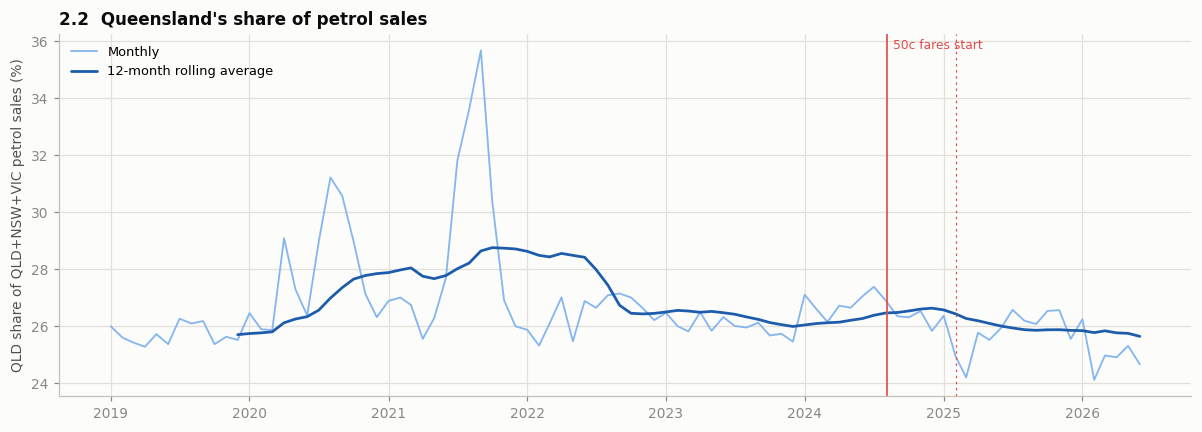

In [9]:
share = 100 * petrol["QLD"] / petrol[["QLD", "NSW", "VIC"]].sum(axis=1)
s = share["2019":]
fig, ax = new_fig()
ax.plot(s.index, s, color=BLUE_LIGHT, lw=1.2, label="Monthly")
ax.plot(s.index, s.rolling(12).mean(), color=BLUE_DARK, label="12-month rolling average")
policy_line(ax); ax.legend(loc="upper left")
ax.set_ylabel("QLD share of QLD+NSW+VIC petrol sales (%)")
ax.set_title("2.2  Queensland's share of petrol sales")
show(fig, "2_2_qld_petrol_share")

> **What we learn:** This is the cleanest picture for RQ2. Queensland's share of the three-state total was 26.4 per cent in the year before the policy and 25.9 per cent in the year after, and it has kept drifting down to about 25.6 per cent. That is roughly a 3 per cent relative drop in petrol sold in Queensland, in the direction the policy would predict. It is small, and the bumps in 2020 and 2021 (Sydney and Melbourne lockdowns) show the share can move for reasons that have nothing to do with Queensland, so the model must confirm it.

### 2.3 Year-on-year change: Queensland versus the controls
**What it shows:** the percentage change in petrol sales against the same month a year earlier, for Queensland and for NSW + VIC combined.
**Look for:** Queensland sitting persistently below the control line after August 2024. A one-month dip is noise. Twelve months below is a signal.

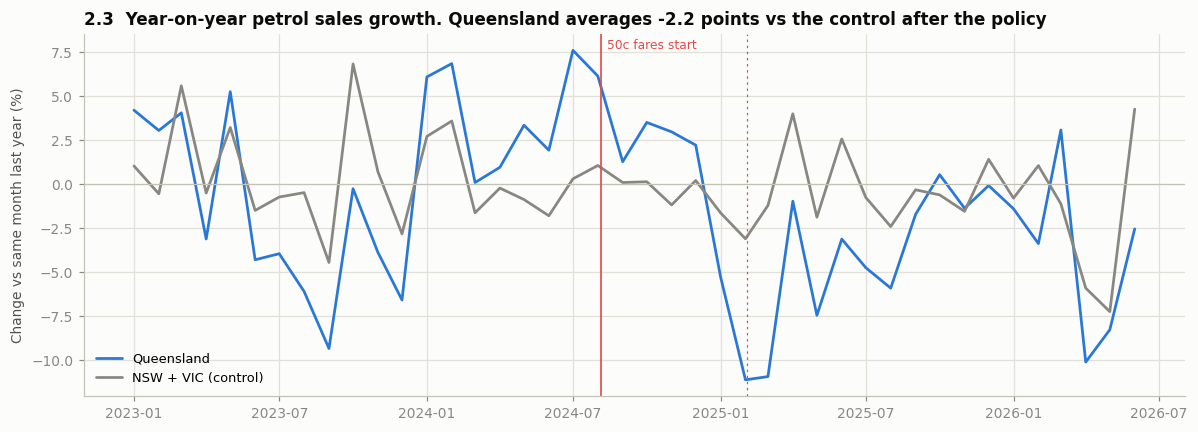

In [10]:
ctrl = petrol["NSW"] + petrol["VIC"]
yq = 100 * (petrol["QLD"] / petrol["QLD"].shift(12) - 1)
yc = 100 * (ctrl / ctrl.shift(12) - 1)
fig, ax = new_fig()
ax.plot(yq["2023":].index, yq["2023":], color=BLUE, label="Queensland")
ax.plot(yc["2023":].index, yc["2023":], color=GRAY_D, label="NSW + VIC (control)")
ax.axhline(0, color=AXIS, lw=0.8); policy_line(ax); ax.legend(loc="lower left")
diff = (yq - yc)[POLICY:].mean()
ax.set_ylabel("Change vs same month last year (%)")
ax.set_title(f"2.3  Year-on-year petrol sales growth. Queensland averages {diff:+.1f} points vs the control after the policy")
show(fig, "2_3_petrol_yoy_vs_control")

> **What we learn:** Since the policy, Queensland's petrol sales have run about 2.9 per cent below a year earlier on average, while NSW and Victoria combined ran 0.7 per cent below. Queensland has underperformed its controls by about 2.2 percentage points a year. This agrees with the share chart: driving fell a little in Queensland, relative to states that did not cut fares.

## RQ3. Did carbon emissions fall? (preview only)

### 3.1 A naive counterfactual for petrol saved
**What it shows:** if Queensland had kept its pre-policy share of three-state petrol sales, how much petrol would it have sold each month? The chart accumulates the difference between that counterfactual and actual sales, then converts litres to CO2 at the standard factor of about 2.3 kg per litre.

**This is deliberately crude.** It ignores the emissions of the extra buses and trains Translink added, and the "share" counterfactual is a placeholder for the real model. Treat the number as the order of magnitude the project is chasing, not as a finding.

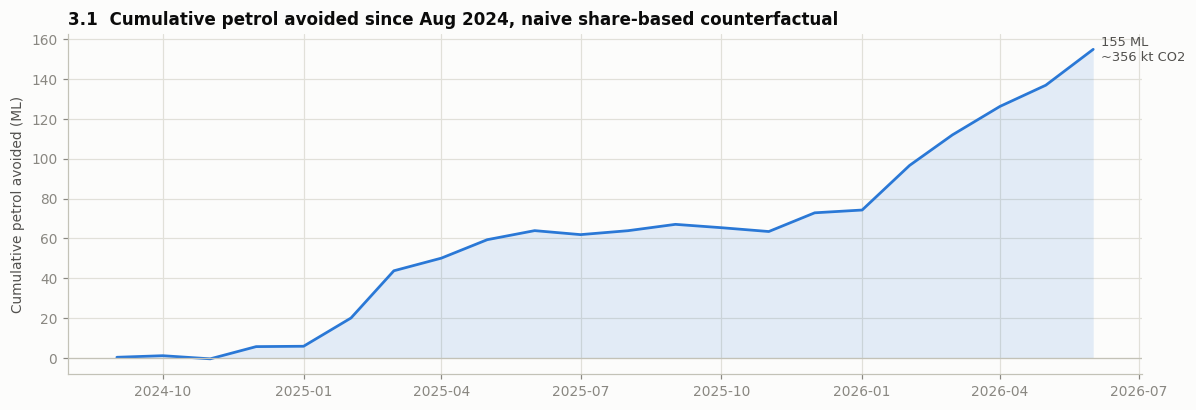

Pre-policy QLD share of three-state petrol sales: 26.37%
Cumulative petrol avoided to Jun 2026: 155 ML  ~  356 kilotonnes CO2 (before subtracting added services)


In [11]:
base_share = (petrol["QLD"] / petrol[["QLD", "NSW", "VIC"]].sum(axis=1))[PRE[0]:PRE[1]].mean()
cf = base_share * petrol[["QLD", "NSW", "VIC"]].sum(axis=1)          # counterfactual QLD sales (ML)
saved_ML = (cf - petrol["QLD"])[POLICY:]                                # positive = petrol avoided
cum = saved_ML.cumsum()
co2_kt = cum * 1e6 * 2.3 / 1e3 / 1e3                                    # ML -> litres (x1e6) -> kg CO2 (x2.3) -> tonnes (/1e3) -> kilotonnes (/1e3)
fig, ax = new_fig(11, 3.8)
ax.fill_between(cum.index, 0, cum, color=BLUE, alpha=0.12, lw=0)
ax.plot(cum.index, cum, color=BLUE)
ax.axhline(0, color=AXIS, lw=0.8)
end_label(ax, cum.index[-1], cum.iloc[-1], f"{cum.iloc[-1]:,.0f} ML\n~{co2_kt.iloc[-1]:,.0f} kt CO2")
ax.set_ylabel("Cumulative petrol avoided (ML)")
ax.set_title("3.1  Cumulative petrol avoided since Aug 2024, naive share-based counterfactual")
show(fig, "3_1_cumulative_petrol_avoided")
print(f"Pre-policy QLD share of three-state petrol sales: {100*base_share:.2f}%")
print(f"Cumulative petrol avoided to {cum.index[-1].strftime('%b %Y')}: {cum.iloc[-1]:,.0f} ML  ~  {co2_kt.iloc[-1]:,.0f} kilotonnes CO2 (before subtracting added services)")

> **What we learn:** If Queensland had kept its pre-policy share of petrol sales, it would have sold about 155 million litres more by June 2026 than it actually did. Burning that petrol would have released roughly 356 kilotonnes of CO2. Treat this as a ceiling: it assumes the whole share drop is due to the policy and ignores the emissions of the extra bus and train services. The real figure will be smaller. What it does tell us is that the prize is measured in hundreds of kilotonnes, not millions.

## RQ4. Did roadside air quality improve?

### 4.1 Nitrogen dioxide at roadside and background monitors
**What it shows:** monthly average NO2 at two roadside sites (South Brisbane, Woolloongabba) and two suburban background sites (Rocklea, Springwood). NO2 near roads comes mostly from vehicle exhaust.
**Look for:** the strong winter peak every year, which is weather, not traffic. Any policy effect has to be found *underneath* that seasonal wave, which is why RQ4 needs a weather-adjusted model rather than a before-and-after average.

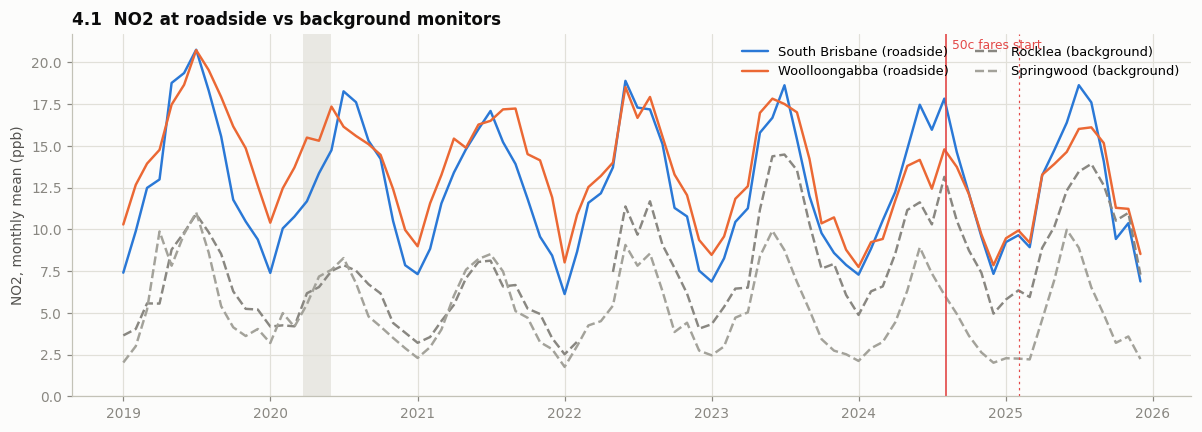

In [12]:
monthly = no2.set_index("ts").groupby("site")["no2_ppb"].resample("MS").mean().unstack(0)
styles = {"southbrisbane": (BLUE, "-", "South Brisbane (roadside)"), "woolloongabba": (ORANGE, "-", "Woolloongabba (roadside)"),
          "rocklea": (GRAY_D, "--", "Rocklea (background)"), "springwood": (GRAY_M, "--", "Springwood (background)")}
fig, ax = new_fig()
for site, (col, ls, lab) in styles.items():
    ax.plot(monthly.index, monthly[site], color=col, ls=ls, label=lab, lw=1.6)
lockdown_band(ax); policy_line(ax); ax.legend(loc="upper right", ncol=2)
ax.set_ylabel("NO2, monthly mean (ppb)"); ax.set_ylim(0, None)
ax.set_title("4.1  NO2 at roadside vs background monitors")
show(fig, "4_1_no2_monthly_sites")

> **What we learn:** Two things dominate this chart, and neither is the policy. NO2 is about twice as high in winter as in summer, because cold still air traps exhaust near the ground. And roadside levels are about double the suburban background, which confirms these monitors do pick up traffic. There is no visible drop after the red line. The seasonal swing is far larger than any policy effect could be, so a raw before-and-after comparison is meaningless here.

### 4.2 The "traffic increment": roadside minus background
**What it shows:** the roadside average minus the background average, month by month. Subtracting the background removes region-wide weather and seasonal effects and leaves the part of NO2 that is due to nearby traffic.
**Look for:** whether the 12-month rolling line steps down after August 2024. This is the cleanest single picture of RQ4 before any modelling.

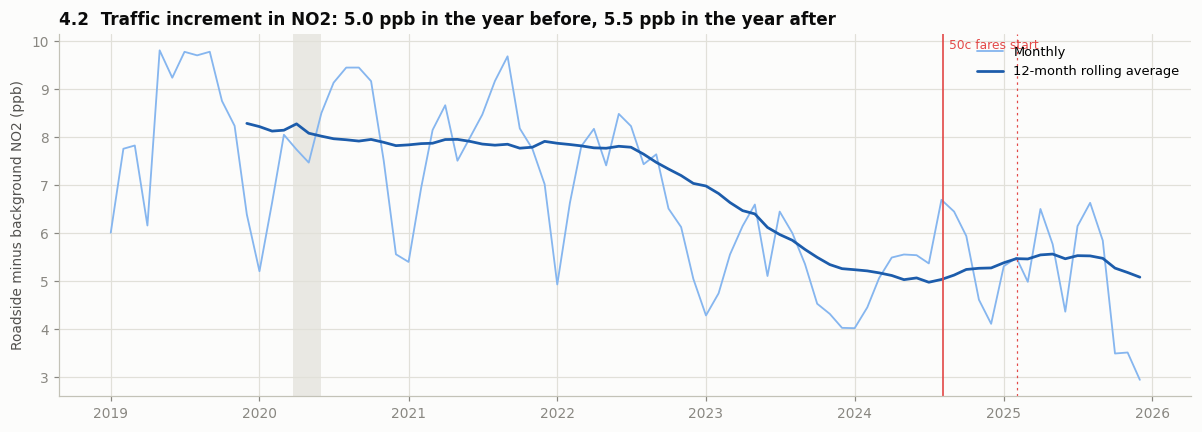

In [13]:
inc = monthly[["southbrisbane", "woolloongabba"]].mean(axis=1) - monthly[["rocklea", "springwood"]].mean(axis=1)
fig, ax = new_fig()
ax.plot(inc.index, inc, color=BLUE_LIGHT, lw=1.2, label="Monthly")
ax.plot(inc.index, inc.rolling(12).mean(), color=BLUE_DARK, label="12-month rolling average")
lockdown_band(ax); policy_line(ax); ax.legend(loc="upper right")
pre_v, post_v = inc[PRE[0]:PRE[1]].mean(), inc[POST[0]:POST[1]].mean()
ax.set_ylabel("Roadside minus background NO2 (ppb)")
ax.set_title(f"4.2  Traffic increment in NO2: {pre_v:.1f} ppb in the year before, {post_v:.1f} ppb in the year after")
show(fig, "4_2_no2_traffic_increment")

> **What we learn:** Subtracting the background removes most of the weather and leaves the part of NO2 caused by nearby traffic. That traffic increment averaged 5.0 ppb in the year before the policy and 5.5 ppb in the year after. It went up, not down. On this evidence the fare cut did not reduce traffic pollution beside Brisbane's roads.

### 4.3 The lockdown ruler: what a real traffic collapse looks like
**What it shows:** the average weekday NO2 at South Brisbane by hour of day, for the same two months (April and May) in four years: 2019 (normal), 2020 (lockdown, when traffic genuinely collapsed), 2024 (the last April-May before the policy) and 2025 (the first April-May under 50-cent fares). Holding the months fixed matters: NO2 is far higher in autumn and winter, so comparing a lockdown window against a full-year average would hide the effect.
**Look for:** the morning and evening peaks. Lockdown 2020 should sit clearly below 2019. If 2025 sits on top of 2024, the fare cut removed far fewer cars than a lockdown did, and the project can say how much smaller the effect must be.

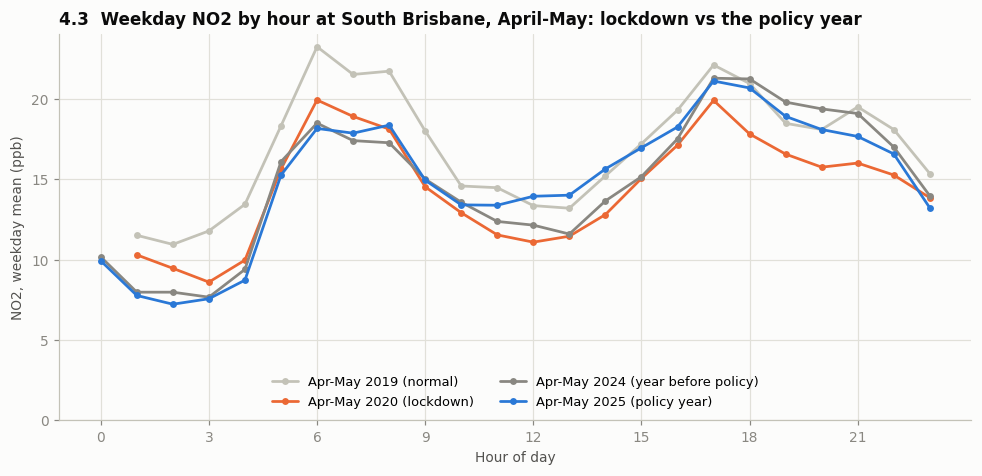

In [14]:
sb = no2[(no2.site == "southbrisbane") & no2.weekday].set_index("ts")
apr_may = lambda y: sb[f"{y}-04-01":f"{y}-05-31"]        # same season every time
periods = {"Apr-May 2019 (normal)": (apr_may(2019), GRAY_L), "Apr-May 2020 (lockdown)": (apr_may(2020), ORANGE),
           "Apr-May 2024 (year before policy)": (apr_may(2024), GRAY_D), "Apr-May 2025 (policy year)": (apr_may(2025), BLUE)}
fig, ax = new_fig(9, 4.4)
for lab, (d, col) in periods.items():
    prof = d.groupby("hour")["no2_ppb"].mean()
    ax.plot(prof.index, prof, color=col, label=lab, marker="o", ms=3.5)
ax.set_xticks(range(0, 24, 3)); ax.set_xlabel("Hour of day"); ax.set_ylabel("NO2, weekday mean (ppb)"); ax.set_ylim(0, None)
ax.set_title("4.3  Weekday NO2 by hour at South Brisbane, April-May: lockdown vs the policy year")
ax.legend(loc="lower center", ncol=2)
show(fig, "4_3_diurnal_lockdown_ruler")

> **What we learn:** The orange lockdown curve sits clearly below the 2019 curve in the morning peak, so a genuine collapse in traffic does show up in this data. The blue policy-year curve sits on top of the grey year-before curve at every hour. Whatever cars the fare cut removed, it was nowhere near enough to move the needle. This chart is the ruler: lockdown-scale traffic loss is visible, fare-cut-scale traffic loss is not.

### 4.4 Peak-hour NO2 change, side by side
**What it shows:** the percentage change in weekday morning-peak NO2 (7 to 9 am) at each roadside site, for two comparisons: lockdown 2020 against the same months in 2019, and the policy year against the year before.
**Look for:** the scale. Lockdown is the size of effect a massive drop in driving produces. The policy-year bar shows what actually happened. Bars left of zero mean cleaner air. The printed table underneath shows how many hours of valid data sit behind each bar. If a site's lockdown bar is near zero despite full coverage, that site did not respond to the 2020 traffic drop and is not a clean traffic monitor for this test; lean on the other one.

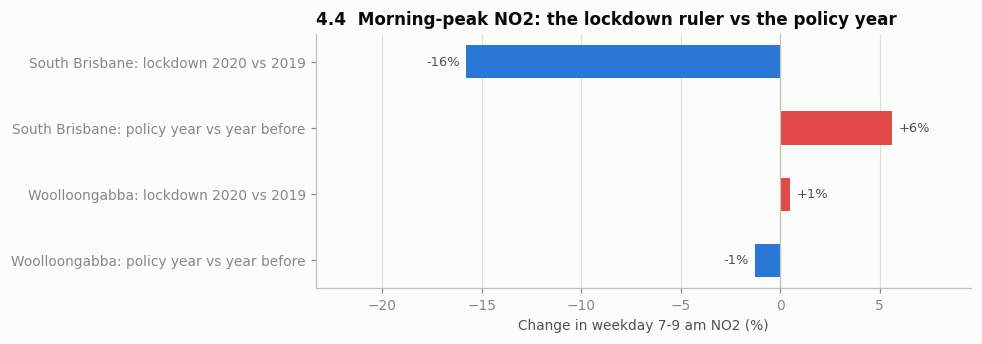

Hours of valid 7-9 am weekday data behind each bar (Apr-May 2019, Apr-May 2020, year before, year after):
  South Brisbane   131  128   778   758
  Woolloongabba    135  128   781   777


In [15]:
def peak_mean(site, start, end):
    d = no2[(no2.site == site) & no2.weekday & no2.hour.between(7, 9)].set_index("ts")[start:end]["no2_ppb"]
    return d.mean(), int(d.notna().sum())
rows, coverage = [], []
for site, lab in [("southbrisbane", "South Brisbane"), ("woolloongabba", "Woolloongabba")]:
    (m20, n20), (m19, n19) = peak_mean(site, "2020-04-01", "2020-05-31"), peak_mean(site, "2019-04-01", "2019-05-31")
    (mpo, npo), (mpr, npr) = peak_mean(site, *POST), peak_mean(site, *PRE)
    rows += [(f"{lab}: lockdown 2020 vs 2019", 100 * (m20 / m19 - 1)), (f"{lab}: policy year vs year before", 100 * (mpo / mpr - 1))]
    coverage.append((lab, n19, n20, npr, npo))
lab, val = zip(*rows)
fig, ax = new_fig(9, 3.2)
cols = [BLUE if v < 0 else RED for v in val]
ax.barh(range(len(val)), val, color=cols, height=0.5)
ax.set_yticks(range(len(val))); ax.set_yticklabels(lab); ax.invert_yaxis()
ax.axvline(0, color=AXIS, lw=0.8)
lo, hi = min(val), max(val); ax.set_xlim(lo - 0.35 * abs(lo) - 2, hi + 0.35 * abs(hi) + 2)
for i, v in enumerate(val):
    ax.annotate(f"{v:+.0f}%", (v, i), xytext=(-4 if v < 0 else 4, 0), textcoords="offset points",
                ha="right" if v < 0 else "left", va="center", fontsize=8.5, color=INK2)
ax.set_xlabel("Change in weekday 7-9 am NO2 (%)"); ax.grid(axis="y", visible=False)
ax.set_title("4.4  Morning-peak NO2: the lockdown ruler vs the policy year")
show(fig, "4_4_peak_no2_change_bars")
print("Hours of valid 7-9 am weekday data behind each bar (Apr-May 2019, Apr-May 2020, year before, year after):")
for c in coverage:
    print(f"  {c[0]:15} {c[1]:4d} {c[2]:4d} {c[3]:5d} {c[4]:5d}")

> **What we learn:** At South Brisbane the 2020 lockdown cut morning-peak NO2 by 16 per cent. The policy year went the other way, up 6 per cent. Woolloongabba did not react even to the lockdown (+1 per cent), so it is not a reliable traffic monitor and should be dropped from the RQ4 model. The data coverage printed below is complete for every bar, so this is not a missing-data artefact.

### 4.5 Why RQ4 needs a weather model: NO2 against wind speed
**What it shows:** median daytime NO2 at South Brisbane in bins of wind speed, for the year before and the year after the policy.
**Look for:** how steeply NO2 falls as the wind picks up. A windy year looks "cleaner" with no change in traffic at all. Comparing the two curves *at the same wind speed* is a fairer before-and-after than comparing raw averages, and it is the idea the RQ4 model will formalise.

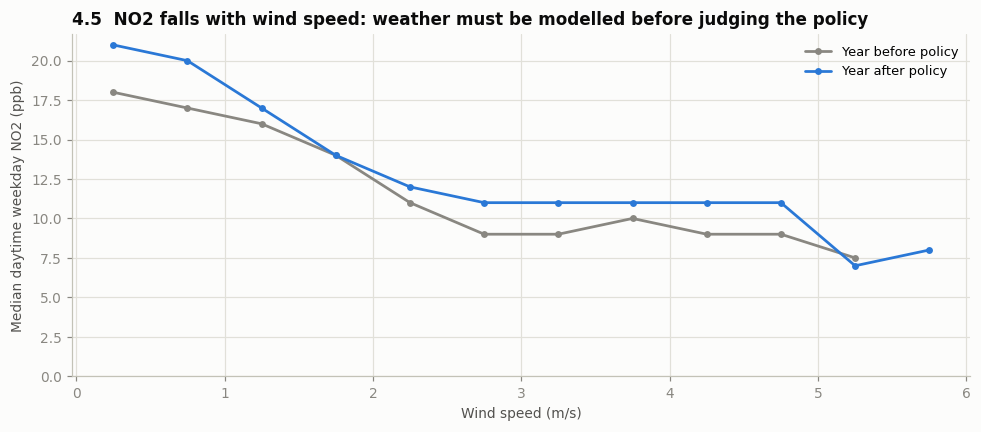

In [16]:
def load_met(site):
    parts = []
    for f in sorted(glob.glob(str(RAW / "air_quality" / f"{site}-aq-*.csv"))):
        for enc in ("utf-8-sig", "cp1252"):
            try:
                x = pd.read_csv(f, encoding=enc); break
            except UnicodeDecodeError:
                continue
        x.columns = [c.strip() for c in x.columns]
        hour = pd.to_timedelta(pd.to_numeric(x["Time"].astype(str).str.split(":").str[0], errors="coerce"), unit="h")
        ts = pd.to_datetime(x["Date"], format="mixed", dayfirst=True, errors="coerce") + hour
        no2c = [c for c in x.columns if c.startswith("Nitrogen Dioxide")][0]
        parts.append(pd.DataFrame({"ts": ts, "no2_ppb": pd.to_numeric(x[no2c], errors="coerce") * 1000,
                                   "wind": pd.to_numeric(x["Wind Speed (m/s)"], errors="coerce")}))
    return pd.concat(parts).dropna(subset=["ts"]).set_index("ts").sort_index()

met = load_met("southbrisbane")
met = met[(met.index.dayofweek < 5) & met.index.hour.isin(range(6, 20))]
bins = np.arange(0, 6.5, 0.5)
fig, ax = new_fig(9, 4)
for lab, (a, b), col in [("Year before policy", PRE, GRAY_D), ("Year after policy", POST, BLUE)]:
    d = met[a:b].dropna()
    grp = d.groupby(pd.cut(d.wind, bins))["no2_ppb"].median()
    ax.plot([i.mid for i in grp.index], grp.values, color=col, marker="o", ms=3.5, label=lab)
ax.set_xlabel("Wind speed (m/s)"); ax.set_ylabel("Median daytime weekday NO2 (ppb)"); ax.set_ylim(0, None)
ax.set_title("4.5  NO2 falls with wind speed: weather must be modelled before judging the policy")
ax.legend(loc="upper right")
show(fig, "4_5_no2_vs_wind")

> **What we learn:** NO2 roughly halves as the wind rises from calm to 3 metres per second. A windy year would look cleaner with no change in traffic at all, and a still year would look dirtier. At the same wind speed the policy year (blue) sits slightly above the year before (grey), so the lack of improvement in 4.4 is not a weather accident. Any fair test of RQ4 has to hold weather constant, which is exactly what the model will do.

## RQ5. Were drivers ever on the margin? Fuel-price sensitivity

### 5.1 The petrol price itself
**What it shows:** the weekly median unleaded price across SEQ servos since 2019.
**Look for:** the 2022 spike (Ukraine war and the temporary fuel excise cut), the regular Brisbane price cycle (the sawtooth), and the fact that prices after August 2024 were no higher than before. Whatever happened to ridership was not driven by a fuel shock at the same time.

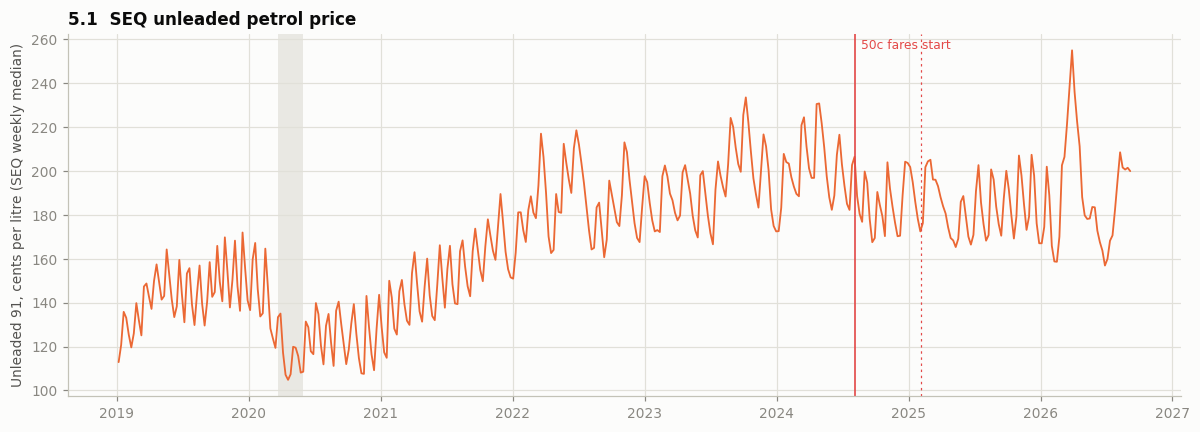

In [17]:
fig, ax = new_fig()
ax.plot(fuel.index, fuel, color=ORANGE, lw=1.2)
lockdown_band(ax); policy_line(ax)
ax.set_ylabel("Unleaded 91, cents per litre (SEQ weekly median)")
ax.set_title("5.1  SEQ unleaded petrol price")
show(fig, "5_1_fuel_price")

> **What we learn:** Petrol averaged about 202 cents a litre in the year before the policy and 185 cents in the year after. Fuel was cheaper, not dearer, when ridership jumped, so petrol prices cannot explain the increase. The chart also shows the 2022 spike to over 218 cents and the regular Brisbane price cycle, which give the model plenty of price variation to work with.

### 5.2 Do trips rise when petrol gets dearer?
**What it shows:** each dot is a week. Horizontal axis: how much dearer petrol was than a year earlier. Vertical axis: how much higher trips were than a year earlier. Grey dots are pre-policy weeks (mid-2022 to July 2024, avoiding COVID base effects); blue dots are the policy year.
**Look for:** whether the grey cloud slopes upward. A clear upward slope means drivers *do* respond to fuel costs, which is the precondition for a fare cut to pull them out of cars. The blue cloud sits higher because of the fare cut itself, not fuel. Two early-2023 weeks whose comparison week was the February 2022 flood shutdown (changes of several hundred per cent) are excluded.

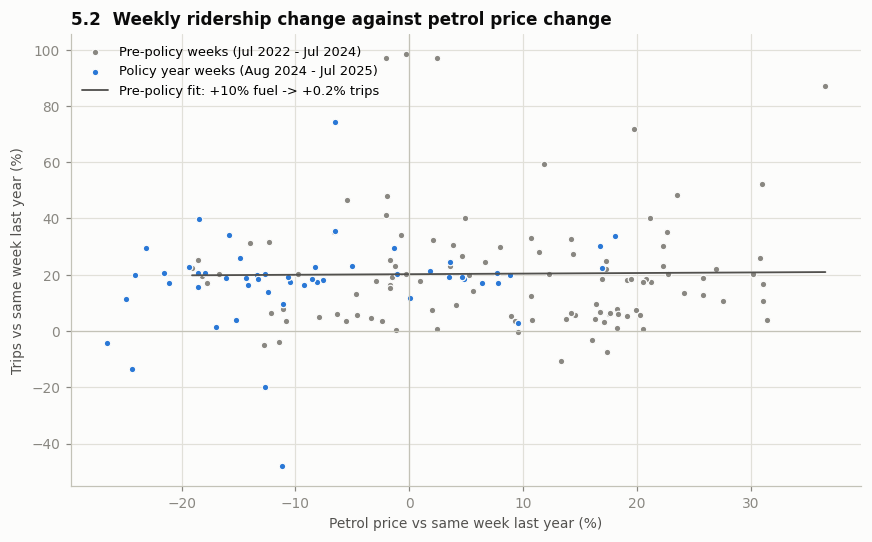

Crude pre-policy relationship: a 10% rise in petrol price goes with a +0.21% change in trips (R = +0.01).


In [18]:
df = pd.DataFrame({"trips_yoy": 100 * (trips / trips.shift(52) - 1),
                   "fuel_yoy": 100 * (fuel.reindex(trips.index) / fuel.reindex(trips.index).shift(52) - 1)}).dropna()
df = df[df.trips_yoy.abs() < 100]        # drop weeks whose comparison week was the Feb-Mar 2022 flood shutdown
pre_w, post_w = df["2022-07-01":"2024-07-28"], df[POLICY:POLICY + pd.Timedelta(weeks=52)]
slope, icpt = np.polyfit(pre_w.fuel_yoy, pre_w.trips_yoy, 1)
fig, ax = new_fig(8, 5)
ax.scatter(pre_w.fuel_yoy, pre_w.trips_yoy, s=18, color=GRAY_D, edgecolor=SURFACE, lw=0.8, label="Pre-policy weeks (Jul 2022 - Jul 2024)")
ax.scatter(post_w.fuel_yoy, post_w.trips_yoy, s=18, color=BLUE, edgecolor=SURFACE, lw=0.8, label="Policy year weeks (Aug 2024 - Jul 2025)")
xs = np.linspace(pre_w.fuel_yoy.min(), pre_w.fuel_yoy.max(), 50)
ax.plot(xs, icpt + slope * xs, color=INK2, lw=1.2, label=f"Pre-policy fit: +10% fuel -> {10*slope:+.1f}% trips")
ax.axhline(0, color=AXIS, lw=0.8); ax.axvline(0, color=AXIS, lw=0.8)
ax.set_xlabel("Petrol price vs same week last year (%)"); ax.set_ylabel("Trips vs same week last year (%)")
ax.set_title("5.2  Weekly ridership change against petrol price change")
ax.legend(loc="upper left")
show(fig, "5_2_trips_vs_fuel_scatter")
print(f"Crude pre-policy relationship: a 10% rise in petrol price goes with a {10*slope:+.2f}% change in trips (R = {pre_w.corr().iloc[0,1]:+.2f}).")

> **What we learn:** The grey cloud is flat. Weeks when petrol was 20 per cent dearer than a year earlier had about the same ridership growth as weeks when it was 20 per cent cheaper. The fitted line says a 10 per cent rise in petrol prices goes with only a 0.2 per cent rise in trips, effectively zero. Brisbane drivers were not waiting for a price signal to switch. That helps explain why a near-free fare pulled in many new riders but few former drivers.

### 5.3 Does the effect arrive with a delay?
**What it shows:** the correlation between a four-week change in petrol prices and the four-week change in trips *k* weeks later, for k = 0 to 8, using pre-policy weeks only.
**Look for:** whether any bar stands clearly above the others. People do not change habits the day petrol goes up; a peak at a lag of two to four weeks would be the natural signature. Flat, near-zero bars everywhere would mean fuel prices barely moved ridership at all, which is itself an important finding for RQ5.

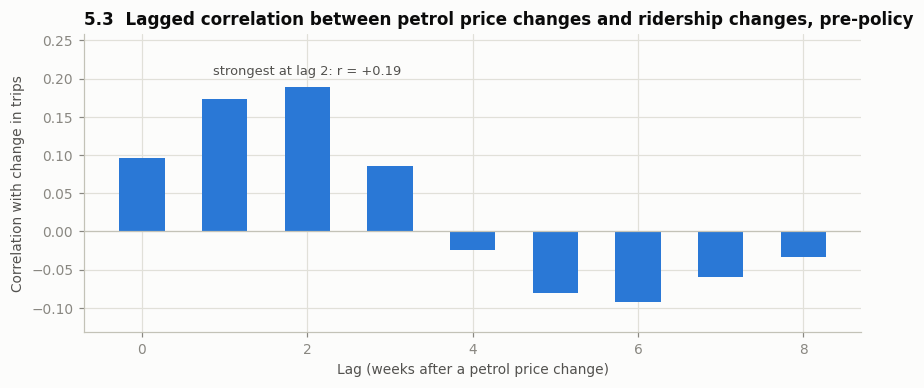

In [19]:
lf = np.log(fuel.reindex(trips.index)).diff(4)
lt = np.log(trips).diff(4)
win = slice("2022-07-01", "2024-07-28")
lags = range(0, 9)
corr = [lt[win].corr(lf.shift(k)[win]) for k in lags]
fig, ax = new_fig(8, 3.6)
ax.bar(list(lags), corr, color=BLUE, width=0.55)
ax.axhline(0, color=AXIS, lw=0.8)
ax.set_ylim(min(corr + [0]) - 0.04, max(corr + [0]) + 0.07)     # headroom for the annotation
k = int(np.argmax(np.abs(corr)))
ax.annotate(f"strongest at lag {k}: r = {corr[k]:+.2f}", (k, corr[k]), xytext=(0, 8 if corr[k] >= 0 else -14),
            textcoords="offset points", ha="center", fontsize=8.5, color=INK2)
ax.set_xlabel("Lag (weeks after a petrol price change)"); ax.set_ylabel("Correlation with change in trips")
ax.set_title("5.3  Lagged correlation between petrol price changes and ridership changes, pre-policy")
show(fig, "5_3_lagged_correlation")

> **What we learn:** There is a faint delayed response: the strongest link is two weeks after a price change, with a correlation of 0.19. That is weak. Petrol prices nudge ridership a little, after a short delay, but they do not drive it. For RQ5 this means the fuel-price channel was never strong, which fits the small environmental effects in sections 2 to 4.

## Side effects worth knowing about

### 6.1 Fines and warnings
**What it shows:** monthly passenger fines and warnings, rebased so the pre-policy months average 100.
**Look for:** whether enforcement activity collapsed once a fare cost 50 cents. If it did, that is a real operational effect of the policy, and it also matters for interpreting the trip counts (fewer fare evaders means more tap-ons recorded).

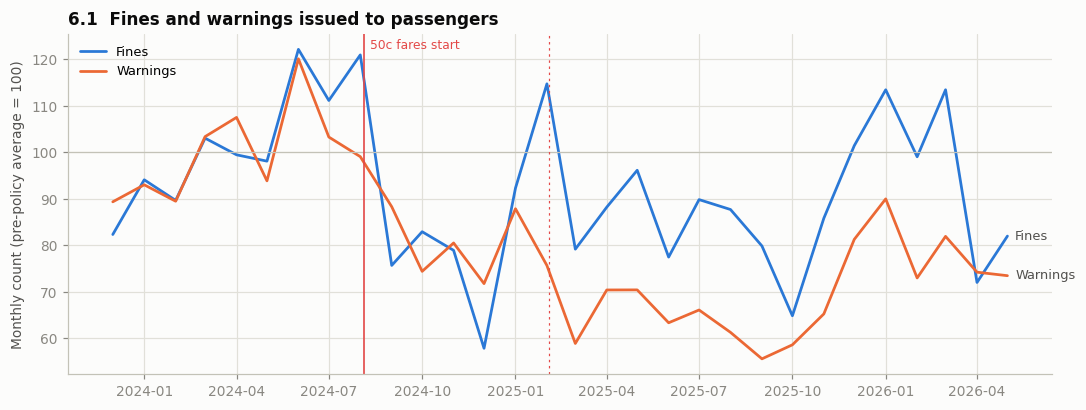

In [20]:
fi = fines.apply(lambda c: index_to(c, "2023-12-01", "2024-07-01"))
fig, ax = new_fig(10, 3.8)
for c, col, lab in [("Passenger fines", BLUE, "Fines"), ("Passenger warnings", ORANGE, "Warnings")]:
    ax.plot(fi.index, fi[c], color=col, label=lab); end_label(ax, fi.index[-1], fi[c].iloc[-1], lab)
ax.axhline(100, color=AXIS, lw=0.8); policy_line(ax); ax.legend(loc="upper left")
ax.set_ylabel("Monthly count (pre-policy average = 100)")
ax.set_title("6.1  Fines and warnings issued to passengers")
show(fig, "6_1_fines_warnings")

> **What we learn:** Both enforcement counts fell after the fare cut. Warnings dropped 24 per cent in the policy year and are still about 21 per cent below the pre-policy level. Fines fell 12 per cent and have mostly recovered. Fewer people dodge a 50-cent fare, or officers issue fewer warnings when the fare is trivial. Either way, it is a real operational side effect of the policy.

### 6.2 Complaints per 10,000 trips
**What it shows:** weekly customer complaints (other than go card issues) for every 10,000 trips, with an 8-week rolling average.
**Look for:** a rise after the red line. More riders on the same fleet means crowding, and crowding shows up here first. This is the "cost" side of the story that a fair report should include.

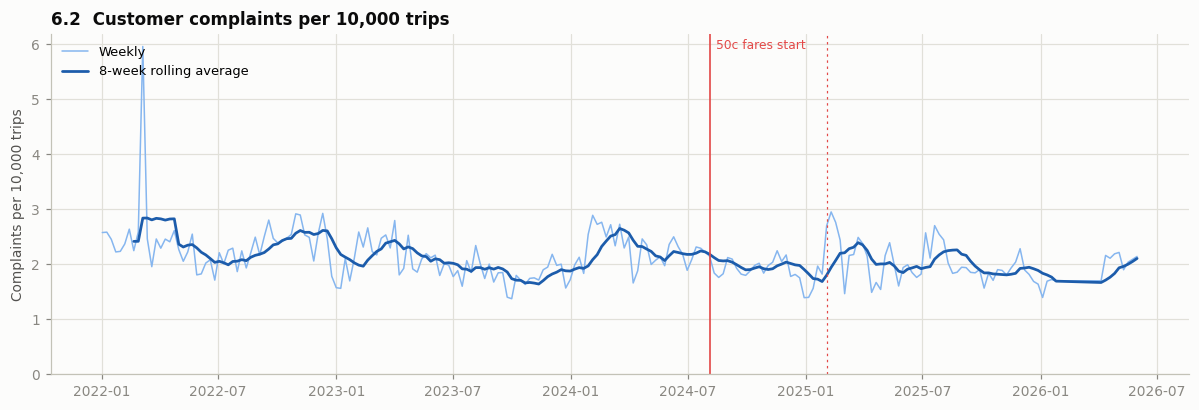

In [21]:
s = pd.to_numeric(complaints, errors="coerce")["2022":]
fig, ax = new_fig(11, 3.8)
ax.plot(s.index, s, color=BLUE_LIGHT, lw=1, label="Weekly")
ax.plot(s.index, s.rolling(8).mean(), color=BLUE_DARK, label="8-week rolling average")
policy_line(ax); ax.legend(loc="upper left")
ax.set_ylabel("Complaints per 10,000 trips"); ax.set_ylim(0, None)
ax.set_title("6.2  Customer complaints per 10,000 trips")
show(fig, "6_2_complaints_per_10k")

> **What we learn:** Complaints per 10,000 trips barely moved: 2.1 in the year before and 2.0 in the year after. Roughly 18 per cent more passengers did not translate into more complaints per rider, so if crowding got worse, riders did not complain about it in proportion.

### 6.3 A data caveat: go card's shrinking share
**What it shows:** the share of all trips paid with a go card. The rest are contactless bank cards, phones and paper tickets.
**Look for:** the steady decline as contactless payment rolled out. Any analysis that uses *go card* trips alone would understate growth. This notebook uses total passenger trips throughout for exactly that reason.

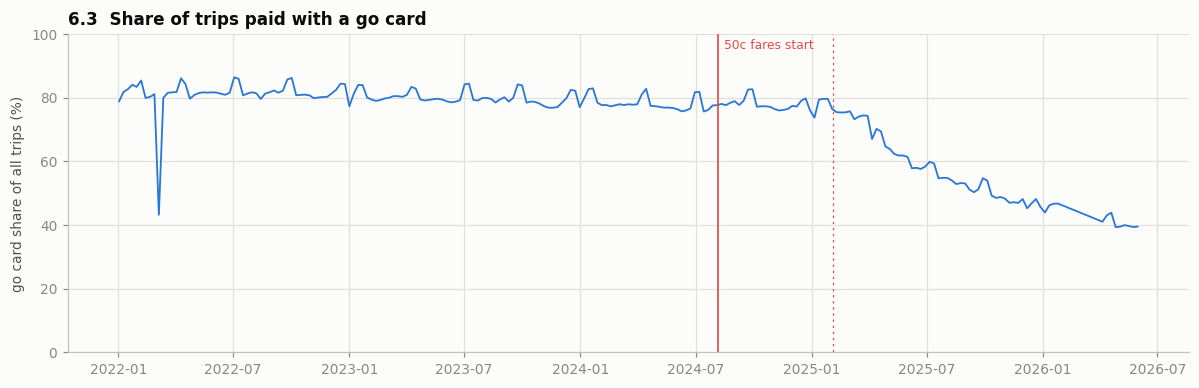

In [22]:
share = (100 * gocard / trips.reindex(gocard.index))["2022":]
fig, ax = new_fig(11, 3.6)
ax.plot(share.index, share, color=BLUE, lw=1.2)
policy_line(ax)
ax.set_ylabel("go card share of all trips (%)"); ax.set_ylim(0, 100)
ax.set_title("6.3  Share of trips paid with a go card")
show(fig, "6_3_gocard_share")

> **What we learn:** In 2022 about 81 per cent of trips were paid with a go card. By July 2024 it was 78 per cent, and in the latest weeks it is about 41 per cent, as contactless bank cards and phones took over. A study that counted only go card trips would conclude ridership fell. This notebook uses total passenger trips everywhere for exactly that reason.

## Conclusions in one place

These are what the charts show before any modelling. Each one is a simple before-and-after comparison, so the model stage can still change the size of every number below.

1. **People rode more, a lot more, and kept riding (RQ1).** Trips jumped about 18 per cent the week fares changed and stayed up for the whole year. In 48 of 52 weeks of 2025 ridership beat the same week of 2019, the best pre-COVID year. Sydney, which did not cut fares, did not move, so the fare cut itself is worth roughly 15 points of the growth.
2. **Many of the new trips are extra outings, not replaced car commutes.** Brisbane's ferries (+32 per cent) and the Gold Coast light rail (+29 per cent) grew far more than buses (+15 per cent). Those are day-out modes.
3. **Driving fell a little (RQ2).** Queensland's share of petrol sold across the three big states slipped from 26.4 to about 25.7 per cent, and Queensland's year-on-year petrol sales ran about 2 points below the control states. Small, in the right direction, not yet proven.
4. **The carbon prize is hundreds of kilotonnes, not millions (RQ3).** The naive ceiling is about 155 million litres of petrol and 356 kilotonnes of CO2 avoided by June 2026, before subtracting the extra buses and trains.
5. **The air did not get cleaner (RQ4).** Roadside NO2 next to Brisbane's roads did not fall; the traffic increment rose from 5.0 to 5.5 ppb and the South Brisbane morning peak was up 6 per cent. The 2020 lockdown, when traffic really collapsed, cut the same reading by 16 per cent. If the fare cut removed cars, it removed far too few for the air to notice.
6. **Petrol prices never moved ridership much (RQ5).** Before the policy, dearer petrol went with essentially no extra public transport use (a 10 per cent price rise, 0.2 per cent more trips). Brisbane drivers were not on the fence, which is why a near-free fare found new riders but few ex-drivers.
7. **Side effects.** Warnings fell about a quarter and fines about a tenth. Complaints per rider did not rise. The go card share of trips has collapsed from 81 to about 41 per cent, so any analysis must use total trips, not go card trips.

**The one-sentence version:** the 50-cent fare was a big win for riders and a small win for petrol use, but the environmental ripple is too small to see in the air so far.

**Next step:** build the counterfactual forecasting model for weekly trips (RQ1), then reuse the same template for petrol sales and NO2. Every chart here becomes a "before" picture that the model output can be laid over, and the numbers above become properly estimated effects with uncertainty ranges.